<a href="https://colab.research.google.com/github/Mais-M/cisa-kev-sql-investigation/blob/main/cisa_kev_sql_investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import requests
import pandas as pd

url = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"

data = requests.get(url).json()
df = pd.DataFrame(data["vulnerabilities"])

print("Dataset shape:", df.shape)

df.to_csv("cisa_kev.csv", index=False)

df.head()

Dataset shape: (1662, 11)


,cveID,vendorProject,product,vulnerabilityName,dateAdded,shortDescription,requiredAction,dueDate,knownRansomwareCampaignUse,notes,cwes
0,CVE-2026-8037,Progress,LoadMaster,Progress LoadMaster Command Injection Vulnerab...,2026-08-07,Progress LoadMaster contains a command injecti...,Apply mitigations in accordance with vendor in...,2026-08-10,Unknown,https://community.progress.com/s/article/LoadM...,[CWE-77]
1,CVE-2026-63077,JetBrains,TeamCity,JetBrains TeamCity Deserialization of Untruste...,2026-08-05,JetBrains TeamCity contains a deserialization ...,Apply mitigations in accordance with vendor in...,2026-08-08,Unknown,https://blog.jetbrains.com/teamcity/2026/07/cv...,[CWE-502]
2,CVE-2026-18556,N-able,N-central,N-able N-central Authentication Bypass Using a...,2026-08-04,N-able N-central contains an authentication by...,Apply mitigations in accordance with vendor in...,2026-08-07,Unknown,https://uptime.n-able.com/ ; https://status.n-...,[CWE-288]
3,CVE-2026-34486,Apache,Tomcat,Apache Tomcat Missing Encryption of Sensitive ...,2026-08-04,Apache Tomcat contains a missing encryption of...,Apply mitigations in accordance with vendor in...,2026-08-07,Unknown,https://lists.apache.org/thread/9510k5p5zdvt9p...,[CWE-311]
4,CVE-2026-9198,IBM,Langflow,IBM Langflow Code Injection Vulnerability,2026-08-04,Langflow contains a code injection vulnerabili...,Apply mitigations in accordance with vendor in...,2026-08-07,Unknown,https://www.ibm.com/support/pages/node/7278927...,[CWE-94]


## SQL Analysis


In [18]:
import duckdb

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE TABLE kev AS
SELECT *
FROM read_csv_auto('cisa_kev.csv')
""")

con.execute("SELECT COUNT(*) AS rows FROM kev").df()

,rows
0,1662


### 1. Top Vendors

In [19]:
top_vendors = con.execute("""
SELECT
    vendorProject,
    COUNT(*) AS vulnerability_count
FROM kev
GROUP BY vendorProject
ORDER BY vulnerability_count DESC
LIMIT 10
""").df()

top_vendors

,vendorProject,vulnerability_count
0,Microsoft,382
1,Cisco,95
2,Apple,93
3,Adobe,80
4,Google,72
5,Oracle,45
6,Apache,40
7,Ivanti,35
8,Fortinet,29
9,VMware,26


### 2. Top Products

In [20]:
top_products = con.execute("""
SELECT
    product,
    COUNT(*) AS vulnerability_count
FROM kev
GROUP BY product
ORDER BY vulnerability_count DESC
LIMIT 10
""").df()

top_products

,product,vulnerability_count
0,Windows,170
1,Multiple Products,79
2,Chromium V8,39
3,Internet Explorer,36
4,Flash Player,33
5,Office,29
6,Kernel,29
7,Win32k,25
8,Exchange Server,17
9,ColdFusion,16


### 3. Ransomware-Associated Vulnerabilities

In [21]:
ransomware_summary = con.execute("""
SELECT
    knownRansomwareCampaignUse,
    COUNT(*) AS vulnerability_count,
    ROUND(
        COUNT(*) * 100.0 / (SELECT COUNT(*) FROM kev),
        1
    ) AS percentage
FROM kev
GROUP BY knownRansomwareCampaignUse
ORDER BY vulnerability_count DESC
""").df()

ransomware_summary

,knownRansomwareCampaignUse,vulnerability_count,percentage
0,Unknown,1324,79.7
1,Known,338,20.3


### 4. Top Vendors Among Known Ransomware-Associated Vulnerabilities

In [22]:
ransomware_vendors = con.execute("""
SELECT
    vendorProject,
    COUNT(*) AS ransomware_related_vulnerabilities
FROM kev
WHERE knownRansomwareCampaignUse = 'Known'
GROUP BY vendorProject
ORDER BY ransomware_related_vulnerabilities DESC
LIMIT 10
""").df()

ransomware_vendors

,vendorProject,ransomware_related_vulnerabilities
0,Microsoft,104
1,Fortinet,13
2,Oracle,13
3,SonicWall,12
4,Ivanti,12
5,Adobe,10
6,QNAP,9
7,VMware,9
8,Atlassian,8
9,Apache,8


### 5. Vulnerabilities Added to the CISA KEV Catalog by Year

In [23]:
yearly = con.execute("""
SELECT
    YEAR(CAST(dateAdded AS DATE)) AS year,
    COUNT(*) AS vulnerabilities_added
FROM kev
GROUP BY year
ORDER BY year
""").df()

yearly

,year,vulnerabilities_added
0,2021,311
1,2022,555
2,2023,187
3,2024,186
4,2025,245
5,2026,178


## Visualizations

### Top 10 Vendors

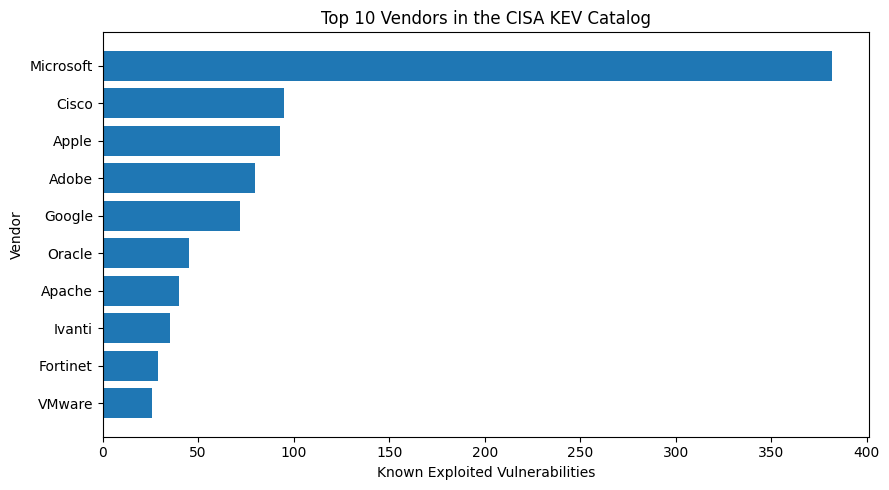

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.barh(
    top_vendors["vendorProject"],
    top_vendors["vulnerability_count"]
)
plt.gca().invert_yaxis()
plt.xlabel("Known Exploited Vulnerabilities")
plt.ylabel("Vendor")
plt.title("Top 10 Vendors in the CISA KEV Catalog")
plt.tight_layout()

plt.savefig("top_vendors.png", dpi=300, bbox_inches="tight")
plt.show()

### CISA KEV Additions by Year

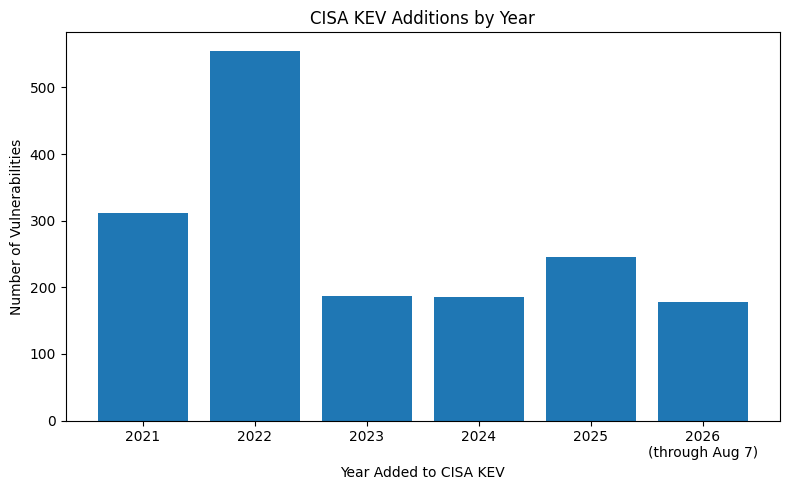

In [25]:
yearly["year_label"] = yearly["year"].astype(str)
yearly.loc[yearly["year"] == 2026, "year_label"] = "2026\n(through Aug 7)"

plt.figure(figsize=(8, 5))
plt.bar(
    yearly["year_label"],
    yearly["vulnerabilities_added"]
)
plt.xlabel("Year Added to CISA KEV")
plt.ylabel("Number of Vulnerabilities")
plt.title("CISA KEV Additions by Year")
plt.tight_layout()

plt.savefig("kev_by_year.png", dpi=300, bbox_inches="tight")
plt.show()